In [1]:
import os    
import math
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from tqdm.auto import tqdm
from torchvision.datasets import ImageFolder
from torchvision import transforms 
from PIL import Image
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from transformers import get_cosine_schedule_with_warmup
import itertools

In [2]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")      # Linux/Windows GPU
elif torch.backends.mps.is_available():
    device = torch.device("mps")       # Mac GPU
else:
    device = torch.device("cpu")       # fallback

print(f"Using device: {device}")
# model.to(device)

Using device: mps


In [3]:
class Sampler:
    def __init__(self, num_training_steps=1000, beta_start=0.0001, beta_end=0.02):
        self.num_training_steps = num_training_steps
        self.beta_start = beta_start
        self.beta_end = beta_end

        ### Define Basic Beta Scheduler ###
        self.beta_schedule = self.linear_beta_schedule()

        ### Compute Alphas for Direction 0 > t Noise Calculation ###
        self.alpha = 1 - self.beta_schedule
        self.alpha_cumulative_prod = torch.cumprod(self.alpha, dim=-1)
    
    def linear_beta_schedule(self):
        """
        Creates the β schedule as a linear ramp from beta_start → beta_end.
        
        Returns: Tensor of shape (T,) 
        e.g. [0.0001, 0.0001018, ..., 0.02]
        """
        return torch.linspace(self.beta_start, self.beta_end, self.num_training_steps)

    def _repeated_unsqueeze(self, target_shape, input):

        """
        Expands `coeff` to have the same number of dimensions as `target_tensor`
        by repeatedly appending trailing size-1 dimensions.
        WHY THIS IS NEEDED (Broadcasting Problem):
        ------------------------------------------
        `coeff` after indexing α_bar has shape: (batch_size,)       ← 1D
        `target_tensor` (the image) has shape:  (batch_size, C, H, W) ← 4D
        PyTorch aligns shapes FROM THE RIGHT when broadcasting:
          coeff        : (batch_size,)
          image        : (batch_size, C, H, W)
          ↳ Would align as: (1, 1, 1, batch_size) — multiplied against WIDTH ❌
        After this function:
          coeff        : (batch_size, 1, 1, 1)
          image        : (batch_size, C, H, W)
          ↳ Aligns as  : scalar per image × every pixel of that image ✅
        Args:
            target_tensor : The tensor whose rank (ndim) we want to match
            coeff         : The 1D coefficient tensor to expand
        Returns:
            coeff reshaped to (batch_size, 1, 1, ...) 
        """
        # Keep appending a trailing dim of size 1 until ranks match
        # Iteration trace for B=2, coeff shape (2,), target 4D:
        #   step 1: 4 > 1 → (2,) becomes (2, 1)
        #   step 2: 4 > 2 → (2, 1) becomes (2, 1, 1)
        #   step 3: 4 > 3 → (2, 1, 1) becomes (2, 1, 1, 1)
        #   step 4: 4 > 4 → False, stop
        while target_shape.dim() > input.dim():
            input = input.unsqueeze(-1)
        return input
    
    def add_noise(self, inputs, timesteps):

        """
        FORWARD DIFFUSION — given a clean image x₀, produce a noisy version x_t.
        Math:  x_t = √ᾱ(t) · x₀  +  √(1-ᾱ(t)) · ε       ε ~ N(0, I)
        Used DURING TRAINING to generate (noisy_image, actual_noise) pairs.
        The network learns to predict the actual_noise from the noisy_image.
        Args:
            inputs    : Clean image tensor, shape (batch, C, H, W)
            timesteps : 1D tensor of timestep indices, shape (batch,)
        Returns:
            noisy_image : Corrupted image at step t
            noise       : The actual noise that was added (training target)
        """
        batch_size, c, h, w = inputs.shape

        ### Grab the Device we want to place tensors on ###
        device = inputs.device
        
        alpha_cumulative_prod_timesteps = self.alpha_cumulative_prod[timesteps].to(device)


        ### For debug and understanding
        # print(timesteps)
        # print(alpha_cumulative_prod_timesteps)
        
        ''' 
        tensor([37,  4, 58, 81])
        tensor([0.9823,         0.9993,          0.9608,           0.9283])
                B1.             B2                 B3                B4
                till-T37.       till-T4.         till-T58
                cum prod ᾱ(t).  cum prod ᾱ(t).     cum prod ᾱ(t)
                0.9823          0.9993             0.9608

        '''
  



        ### Compute Mean Coefficient ###

        #  x_t = √ᾱ · x₀ + √(1-ᾱ) · ε
        # This is √ᾱ · x₀
        mean_coeff = alpha_cumulative_prod_timesteps ** 0.5

        ### Compute Variance Coefficient ###
        # √(1-ᾱ) · ε
        var_coeff = (1 - alpha_cumulative_prod_timesteps) ** 0.5

        ### Reshape mean_coeff and var_coeff to have shape (batch x 1 x 1 x 1) so we can broadcast with input (batch x c x height x width) ###


        # print(f"shape of mean {mean_coeff.shape}")
        # print(f"shape of input {inputs.shape}")

        '''
        shape of mean torch.Size([4])
        shape of input torch.Size([4, 3, 64, 64])

        so we need to reshape the mean as per the input shape 
        one solution is 
        mean = mean.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1) # shape [4, 1, 1, 1] == input.shape

        robust solution create a function and by a loop match the dimension
        thats what _repeated_unsqueeze() does 
        '''
        
        mean_coeff = self._repeated_unsqueeze(inputs, mean_coeff)
        var_coeff = self._repeated_unsqueeze(inputs, var_coeff)

        ## Generate some Noise X ~ N(0,1) (rand_like will automatically place on same device as the inputs) ###
        noise = torch.randn_like(inputs)
        ### Compute Mean (mean_coef * x_0) ###
        mean = mean_coeff * inputs
        ### Compute Variance ###
        var = var_coeff * noise

        ### Compute Noisy Data ###
        noisy_image = mean + var

        # print(f"shape of noisy image is {noisy_image.shape} and shape of noise is {noise.shape}")
        return noisy_image, noise
        
    def remove_noise(self, input, timestep, predicted_noise):

        """
        REVERSE DIFFUSION — given a noisy image x_t and the model's predicted noise,
        take ONE denoising step backward to get x_{t-1}.
        Math (DDPM reverse step):
            μ  = (1/√α_t) · (x_t − (β_t / √(1-ᾱ_t)) · ε_θ)
            σ² = β_t · (1 − ᾱ_{t-1}) / (1 − ᾱ_t)
            x_{t-1} = μ + σ · z       z ~ N(0, I)   (z = 0 at t=0)
        Called DURING GENERATION, going from t=999 down to t=0.

        
        Args:
            input           : Noisy image x_t,     shape (batch, C, H, W)
            timestep        : Current step index t, shape (batch,)
            predicted_noise : ε_θ predicted by the neural net, shape (batch, C, H, W)
        Returns:
            denoised: Slightly cleaner image x_{t-1}
        """


        assert (input.shape == predicted_noise.shape), "Shapes of noise pattern and input image must be identical!!"
        
        b, c, h, w = input.shape

        ### Grab Device to Place Tensors On ###
        device = input.device

        ### Create mask for if timestep is 0 ###

        ### to handle the edge case for beta_telda_t (variance)
        equal_to_zero_mask = (timestep == 0) # shape (B, ) for each sample in a batch one time step 

        ### Grab Needed Alphas and Betas ###
        beta_t = self.beta_schedule[timestep].to(device)
        alpha_t = self.alpha[timestep].to(device)
        alpha_cumulative_prod_t = self.alpha_cumulative_prod[timestep].to(device)
        alpha_cumulative_prod_t_prev = self.alpha_cumulative_prod[timestep - 1].to(device)

        ### For prev handle exception for timestep=0 ###
        ### This is an empty product with standard to set to 1: https://en.wikipedia.org/wiki/Empty_product
        alpha_cumulative_prod_t_prev[equal_to_zero_mask] = 1 

        ### Sample Noise ###
        noise = torch.randn_like(input)

        #############################################################################
        ### Compute Variance (b_t * (1 - cumulative_a_(t-1)) / (1 - cumulative_a))###
        variance = beta_t * (1 - alpha_cumulative_prod_t_prev) / (1 - alpha_cumulative_prod_t)

        ### Add Dummy Dimensions ###
        variance = self._repeated_unsqueeze(input, variance)

        ### Compute Variance Term (sigma_t_z) ###
        sigma_t_z = noise * variance**0.5
        #############################################################################

        #############################################################################
        ### Compute Mean Term:
        ### (1 - a_t) / sqrt(1 - cumulative_a) -> b_t / sqrt(1 - cumulative_a)###
        noise_coefficient = beta_t / (1 - alpha_cumulative_prod_t)**0.5
        noise_coefficient = self._repeated_unsqueeze(input, noise_coefficient)
        
        ### 1 / sqrt(a_t)
        reciprocal_root_a_t = alpha_t ** -0.5
        reciprocal_root_a_t = self._repeated_unsqueeze(input, reciprocal_root_a_t)
        
        ### Compute Mean ###
        mean = denoised = reciprocal_root_a_t * (input - (noise_coefficient * predicted_noise))
        #############################################################################
        
        ### Compute Denoised Image ###
        denoised = mean + sigma_t_z
        # print(f"shape of denoised sample is {denoised.shape}")
        return denoised

In [ ]:
sampler = Sampler()
rand = torch.randn(4, 3, 64, 64) # images batch of 4 having CHW 
rand_time = torch.randint(0, 100, (4,)) # randomly sample 4 timesteps for a batch [0, 1000]
pred_noise = torch.randn(4, 3, 64, 64)

# sampler.add_noise(rand_input, rand_time)
sampler.remove_noise(rand, rand_time, predicted_noise=pred_noise)

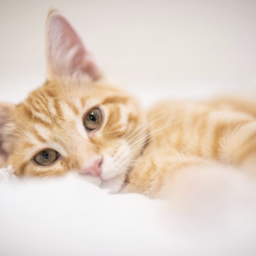

In [6]:
### Define an Image Size ###
image_size = 256

### Load Image ###
image = Image.open("/Users/sachin/Documents/diffusion/data/test_image/sample_image.png").convert("RGB")

### Init Sampler ###
sampler = Sampler()

### Transformations ###
image2tensor_transform = transforms.Compose([
                    transforms.Resize((image_size, image_size)), # Resize Image
                    transforms.ToTensor(), # Convert to tensor (will scale from 0 to 1)
                    transforms.Lambda(lambda t: (t*2) - 1), # Change scale to be -1 to 1
                    transforms.Lambda(lambda t: t.unsqueeze(0))
])

tensor2image_transform = transforms.Compose([
        transforms.Lambda(lambda t: t.squeeze(0)), # Remove batch dimension on
        transforms.Lambda(lambda t: (t + 1) / 2), # Scale back to 0 to 1
        transforms.Lambda(lambda t: t.permute(1, 2, 0)), # Make channels last 
        transforms.Lambda(lambda t: t * 255.), # Scale back to 0 to 255
        transforms.Lambda(lambda t: t.cpu().numpy().astype(np.uint8)), # Convert to numpy
        transforms.ToPILImage(), # Conver to PIL
    ])


### Check Transforms ###
tensor2image_transform(image2tensor_transform(image)).convert("RGB")

### Init Sampler ###
sampler = Sampler()

### Transformations ###
image2tensor_transform = transforms.Compose([
                    transforms.Resize((image_size, image_size)), # Resize Image
                    transforms.ToTensor(), # Convert to tensor (will scale from 0 to 1)
                    transforms.Lambda(lambda t: (t*2) - 1), # Change scale to be -1 to 1
                    transforms.Lambda(lambda t: t.unsqueeze(0))
])

tensor2image_transform = transforms.Compose([
        transforms.Lambda(lambda t: t.squeeze(0)), # Remove batch dimension on
        transforms.Lambda(lambda t: (t + 1) / 2), # Scale back to 0 to 1
        transforms.Lambda(lambda t: t.permute(1, 2, 0)), # Make channels last 
        transforms.Lambda(lambda t: t * 255.), # Scale back to 0 to 255
        transforms.Lambda(lambda t: t.cpu().numpy().astype(np.uint8)), # Convert to numpy
        transforms.ToPILImage(), # Conver to PIL
    ])


### Check Transforms ###
tensor2image_transform(image2tensor_transform(image))

In [7]:
class SelfAttention(nn.Module):
    
    def __init__(self, in_channel,
                num_heads = 12,
                att_p = 0, proj_p = 0
                ):
        super().__init__()
        # assert in_channel % num_heads == 0
        self.num_heads = num_heads 
        self.head_dim = in_channel // num_heads 
        self.scale = self.head_dim ** -0.5 # 1/sqrt(head_dim)

        self.q = nn.Linear(in_channel, in_channel)
        self.k = nn.Linear(in_channel, in_channel)
        self.v = nn.Linear(in_channel, in_channel)

        self.att_p = att_p 
        self.proj = nn.Linear(in_channel,in_channel)
        self.proj_drop = nn.Dropout(proj_p)


    def forward(self, x):
        b, seq_len, d_in = x.shape 
        query = self.q(x).reshape(b, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        key   = self.k(x).reshape(b, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        value = self.v(x).reshape(b, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)

        context_vec = F.scaled_dot_product_attention(query, key, value, dropout_p = self.att_p)
        # # # context_vec = attn_score @ value
        context_vec = context_vec.permute(0, 2, 1, 3).reshape(b, seq_len, d_in) # (b, nh, seq, hd) → (b, seq, nh, hd) → (b, seq, d_in)
        proj = self.proj(context_vec)
        proj = self.proj_drop(proj) 

        return proj

class MLP(nn.Module):
    # 2 layer percptron NN
    def __init__(self, in_channel, mlp_ratio = 4, mlp_p = 0):
        super().__init__()
        self.in_channel = in_channel 
        self.mlp_ratio = mlp_ratio
        self.mlp_p = mlp_p 

        self.fc1 = nn.Linear(in_channel, in_channel*mlp_ratio)
        self.act = nn.GELU()
        self.drop1 = nn.Dropout(mlp_p)
        self.fc2 = nn.Linear(in_channel*mlp_ratio, in_channel)
        self.drop2 = nn.Dropout(mlp_p)


    def forward(self, x):
        b, seq_len, in_channel = x.shape 
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop1(x)
        x = self.fc2(x)
        # x = self.act(x)
        x = self.drop2(x) 

        return x 

class TransformerBlock(nn.Module):
    def __init__(self,
                in_channel,
                num_heads = 4, 
                mlp_ratio = 4,
                mlp_p = 0,
                att_p = 0,
                proj_p = 0,
    ):
        super().__init__()
        self.norm1 = nn.LayerNorm(in_channel, eps = 1e-6)
        self.attn  = SelfAttention(in_channel,num_heads, att_p, proj_p)
        self.norm2 = nn.LayerNorm(in_channel, eps = 1e-6)
        self.mlp = MLP(in_channel, mlp_ratio, mlp_p)

    def forward(self, x):
        b, c, h, w = x.shape 
        x = x.reshape(b, c, h*w)
        x = x.permute(0, 2, 1)
        b, seq_len, in_channel = x.shape  

        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x)) 

        x = x.permute(0, 2, 1)
        x = x.reshape(b, c, h, w) 

        return x 

class SinusodialTimeEmbeddings(nn.Module):
    def __init__(self, time_embed_dim, scaled_time_embed_dim):

        super().__init__() 
        self.inv_freq = nn.Parameter(1.0 / (10000 ** (torch.arange(0, time_embed_dim, 2).float() / time_embed_dim)), requires_grad=False)
        # if time_embed_dim = 128,  64 indexes for sin and 64 for cosine  
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embed_dim, scaled_time_embed_dim),
            nn.SiLU(),
            nn.Linear(scaled_time_embed_dim, scaled_time_embed_dim),
            nn.SiLU()
            )  

    def forward(self, timesteps):
        # timesteps.shape = (b,)
        timestep_freqs = timesteps.unsqueeze(1) * self.inv_freq.unsqueeze(0) # pos * inv_freq
        embeddings = torch.cat([torch.sin(timestep_freqs), torch.cos(timestep_freqs)], dim=-1) # shape [B, time_embed_dim]
        embeddings = self.time_mlp(embeddings) # shape (b, scaled_time_embed_dim)

        return embeddings



In [8]:
rand = torch.randn(4, 64, 14, 14)
t = TransformerBlock(in_channel=64, num_heads=4)
z = t(rand) 
print(z.shape) 
# timesteps = torch.tensor([3, 56, 78])
# STE = SinusodialTimeEmbeddings(128, 256)
# z = STE(timesteps)
# z.shape

torch.Size([4, 64, 14, 14])


In [9]:
### adding time mebedding to image -> X(t)
random_image = torch.randn(4, 64, 32, 32) # B, C, H, W 
print("Image Tensor", random_image.shape) 

### Our random images have 64 channels, so our embeddings need to have a d_model of 64 ### 
random_time_embeddings = torch.randn(4, 64) # this we will get from SinusodialTimeEmbeddings() class 
print("Original Time Embeddings", random_time_embeddings.shape)

time_embeddings = random_time_embeddings.unsqueeze(-1).unsqueeze(-1)
print("Updated Time Embeddings", time_embeddings.shape)

# now add image + time embeddings 
image_at_t = random_image + time_embeddings  
print("Image Tensor at time T", image_at_t.shape) 


Image Tensor torch.Size([4, 64, 32, 32])
Original Time Embeddings torch.Size([4, 64])
Updated Time Embeddings torch.Size([4, 64, 1, 1])
Image Tensor at time T torch.Size([4, 64, 32, 32])


In [10]:
class ResidualBlock(nn.Module):
    def __init__(self,
                in_channels, out_channels,
                groupnorm_num_groups,
                
                time_embed_dim
    ):
        super().__init__() 

        # time embed dim must be equal to out channels 
        # so expand it 
        self.time_expand = nn.Linear(time_embed_dim, out_channels)

        #Conv + GroupNorm
        self.groupnorm_1 = nn.GroupNorm(groupnorm_num_groups, in_channels)
        # we want to increase the channel depth but want to ratain the H,W so padding is "same"
        self.conv_1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same")

        self.groupnorm_2 = nn.GroupNorm(groupnorm_num_groups, out_channels)
        self.conv_2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same")

        self.resize_channels = nn.Conv2d(in_channels, out_channels, kernel_size=1, padding="same") if in_channels!= out_channels else nn.Identity()

    def forward(self, x, time_embeddings):
        # we will get time embeddings from SinusodialTimeEmbeddings()
        residual_connection = x 

        time_embed = self.time_expand(time_embeddings) # [b, out_channels]

        x = self.groupnorm_1(x)
        x = F.silu(x)
        x = self.conv_1(x) 

        # add time embeddings 
        time_embeddings = time_embed.unsqueeze(-1).unsqueeze(-1)
        x = x + time_embeddings # x is image_embed_at time_t

        x = self.groupnorm_2(x)
        x = F.silu(x)
        x = self.conv_2(x)

        # print(x.shape)
        # print(residual_connection.shape) 

        # x = x + residual_connection # this will not work if in_ch != out_ch
        # so we have to fix this by resizing the channels

        x = x + self.resize_channels(residual_connection)

        return x 

    


rand = torch.randn(4, 64, 128, 128) # b, in_ch, H, W
time_embeddings = torch.randn(4, 256)   # b, time_embed_dim 
rb = ResidualBlock(64, 128, 16, 256) 
out = rb(rand, time_embeddings)
out.shape


torch.Size([4, 128, 128, 128])

In [11]:
class UpSampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding='same')
        )

    def forward(self, inputs):
        batch, channels, height, width = inputs.shape
        upsampled = self.upsample(inputs)
        assert (upsampled.shape == (batch, channels, height*2, width*2))
        return upsampled

rand = torch.randn(4, 64, 128, 128)
upsample = UpSampleBlock(64, 64) # in_ch == out_ch we just upsampling will retain the channels
y = upsample(rand) 
y.shape

torch.Size([4, 64, 256, 256])

In [12]:
class UNET(nn.Module):
    def __init__(self,
        start_dim = 64,
        in_channels = 3, 
        out_channels = 64, 
        dim_mults = (1, 2, 4), # channels 64 -> 128 -> 256 
        residual_blocks_per_group = 1,
        groupnorm_num_groups = 16,
        time_embed_dim = 128
    ):
        super().__init__() 
        self.input_image_channels = in_channels
        channel_sizes  = [start_dim*i for i in dim_mults]
        # print(channel_sizes)
        starting_channel_size, ending_channel_size = channel_sizes[0], channel_sizes[-1]

        self.encoder_config = []
        for idx, d in enumerate(channel_sizes):
            for _ in range(residual_blocks_per_group):
                self.encoder_config.append(((d, d), "residual"))

            self.encoder_config.append(((d, d), "downsample"))
            self.encoder_config.append((d, "attention"))


            # thebtransition conv is right now same 
            # we want the transition 64 -> 128 in each transition 
            # we dont need to do this for last transition 
            if idx < len(channel_sizes) - 1: # if we are not at the last index
                self.encoder_config.append(((d, channel_sizes[idx+1]), "residual"))

        # print(self.encoder_config)

        self.bottleneck_config = []

        for _ in range(residual_blocks_per_group):
            self.bottleneck_config.append(((ending_channel_size, ending_channel_size), "residual"))

        out_dim = ending_channel_size 
        reversed_encoder_config = self.encoder_config[::-1]

        # decoder is the mirror image of encoder in the reverse order 
        self.decoder_config = []
        for idx, (metadata, l_type) in enumerate(reversed_encoder_config):
            # print(idx, metadata, l_type)

            if l_type != "attention":
                enc_in_channels, enc_out_channels = metadata 

                self.decoder_config.append(
                    (
                        (out_dim + enc_out_channels, enc_in_channels),
                        "residual"
                    )
                )
            
                if l_type == "downsample":
                    self.decoder_config.append(((enc_in_channels, enc_in_channels), "upsample"))

                out_dim = enc_in_channels 

            else:
                in_channels = metadata 
                self.decoder_config.append((in_channels, "attention")) 

        ### Add Extra Residual Block for residual from input convolution ###
        # hint: We know that the initial convolution will have starting_channel_size
        # and the output of our decoder will also have starting_channel_size, so the
        # final ResidualBlock we need will need to go from starting_channel_size*2 to starting_channel_size

        self.decoder_config.append(((starting_channel_size*2, starting_channel_size), "residual"))

        
        # Build the encoder conv block 
        self.conv_in_proj = nn.Conv2d(
            self.input_image_channels, starting_channel_size, 
            kernel_size = 3, 
            padding = "same"
        )
        self.encoder = nn.ModuleList()  # list of nn modules we will append
        for metadata, l_type in self.encoder_config:
            if l_type == "residual":
                in_ch, out_ch = metadata 
                self.encoder.append(
                    ResidualBlock(in_channels=in_ch, out_channels=out_ch, 
                    groupnorm_num_groups=groupnorm_num_groups, time_embed_dim = time_embed_dim)
                )
            elif l_type == "downsample":
                in_ch, out_ch = metadata 
                self.encoder.append(
                    nn.Conv2d(in_channels=in_ch, out_channels=out_ch,
                    kernel_size = 3, stride=2, padding=1)
                )
            elif l_type == "attention":
                in_ch = metadata 
                self.encoder.append(
                    TransformerBlock(in_channel=in_ch) # this returns a tensor of (b, c, h, w)
                )
        # building encoder bottleneck 
        self.bottleneck = nn.ModuleList()
        for (in_channels, out_channels), _ in self.bottleneck_config:
            self.bottleneck.append(
                ResidualBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    groupnorm_num_groups=groupnorm_num_groups,
                    time_embed_dim=time_embed_dim
                )
            )
         
         # bulding decoder block. 

        self.decoder = nn.ModuleList() 
        for metadata, l_type in self.decoder_config:
            if l_type == "residual":
                in_ch, out_ch  = metadata
                self.decoder.append(
                    ResidualBlock(in_channels=in_ch, out_channels=out_ch,
                    groupnorm_num_groups = groupnorm_num_groups,
                    time_embed_dim=time_embed_dim)
                )

            elif l_type == "upsample":
                in_channels, out_channels = metadata
                self.decoder.append(UpSampleBlock(in_channels=in_channels, 
                                                  out_channels=out_channels))

            elif l_type == "attention":
                in_channels = metadata
                self.decoder.append(TransformerBlock(in_channels))

        # projected conv to match with input_image_channels
        self.conv_out_proj = nn.Conv2d(in_channels=starting_channel_size, 
                                       out_channels=self.input_image_channels,
                                       kernel_size=3, 
                                       padding="same")


    def forward(self, x, time_embeddings):
        residuals = [] 

        # Pass Through Projection and Store Residual
        x = self.conv_in_proj(x) 
        residuals.append(x) 

        #pass through encoder and store the residuals 
        for module in self.encoder:
            if isinstance(module, (ResidualBlock)):
                x = module(x, time_embeddings) # passing time_embeddings from STE()
                residuals.append(x) 
            elif isinstance(module, nn.Conv2d):
                x = module(x)
                residuals.append(x) 
            else:
                x = module(x) 

        for module in self.bottleneck:
            x = module(x, time_embeddings)

        for module in self.decoder:
            if isinstance(module, ResidualBlock):
                residual_tensor = residuals.pop() 
                x = torch.cat([x, residual_tensor], axis = 1)
                x = module(x, time_embeddings)
            else:
                x = module(x) 


        x = self.conv_out_proj(x)
        return x 



m = UNET(start_dim=128, dim_mults=(1, 2))
rand_image = torch.randn(4, 3, 256, 256)
rand_time_embeddings = torch.randn(4, 128)
out = m(rand_image, rand_time_embeddings)
out.shape            



torch.Size([4, 3, 256, 256])

In [13]:
class Diffusion(nn.Module):
    def __init__(self, 
                 in_channels=3, 
                 start_dim=64, 
                 dim_mults=(1,2,4,4), 
                 residual_blocks_per_group=1, 
                 groupnorm_num_groups=16, 
                 time_embed_dim=128, 
                 time_embed_dim_ratio=2):

        super().__init__()
        self.in_channels = in_channels
        self.start_dim = start_dim
        self.dim_mults = dim_mults
        self.residual_blocks_per_group = residual_blocks_per_group
        self.groupnorm_num_groups = groupnorm_num_groups

        self.time_embed_dim = time_embed_dim
        self.scaled_time_embed_dim = int(time_embed_dim * time_embed_dim_ratio)

        self.sinusoid_time_embeddings = SinusodialTimeEmbeddings(time_embed_dim=self.time_embed_dim,
                                                                scaled_time_embed_dim=self.scaled_time_embed_dim)

        self.unet = UNET(in_channels=in_channels, 
                         start_dim=start_dim, 
                         dim_mults=dim_mults, 
                         residual_blocks_per_group=residual_blocks_per_group, 
                         groupnorm_num_groups=groupnorm_num_groups,  
                         time_embed_dim=self.scaled_time_embed_dim)

    def forward(self, noisy_inputs, timesteps):

        ### Embed the Timesteps ###
        timestep_embeddings = self.sinusoid_time_embeddings(timesteps)
        
        ### Pass Images + Time Embeddings through UNET ###
        # we will pass noisy image to UNET() 
        # the pred noise is the output of the UNET model 
        noise_pred = self.unet(noisy_inputs, timestep_embeddings)


        # predicted_noise : ε_θ(Xt, t) predicted by the neural net which is Diffusion NN, shape (batch, C, H, W)
        return noise_pred 

noisy_inputs = torch.randn(4, 3, 64, 64)
timesteps = torch.tensor([34, 76, 16, 98])
Diff = Diffusion()
diff = Diff(noisy_inputs, timesteps)
diff.shape

    

torch.Size([4, 3, 64, 64])

In [14]:
@torch.no_grad()

def sample_plot_image(step_idx, # reference to the training steps lets say 50k steps, index of that 
                      total_timesteps, # T = 1000 diffusion steps
                      sampler, # Diffusion Sampler
                      image_size,
                      num_channels,
                      plot_freq, # after certain number of duration we will plot the image 
                      model,
                      num_gens,  # how many pictures we want to visualize 
                      path_to_generated_dir,
                      device):

    ### Conver Tensor back to Image (From Huggingface Annotated Diffusion) ###
    tensor2image_transform = transforms.Compose([
        transforms.Lambda(lambda t: t.squeeze(0)),
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1, 2, 0)),
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.cpu().numpy().astype(np.uint8)),
        transforms.ToPILImage(),
    ])

    images = torch.randn((num_gens, num_channels, image_size, image_size))
    num_images_per_gen = (total_timesteps // plot_freq) # 1000 // 50 == 20 images per gen 

    images_to_viz = [[] for _ in range(num_gens)]
    for t in np.arange(total_timesteps)[::-1]: # in rev diff T -> 1 

        # The reason why DDPM is slow because of this 
        # we have to go from T -> 1 Sequentially 
        # in DDIM we dont need to traverse from T -> 1

        #lets say 50 images 
        #(50, ) -> [T1, T980, T567, --------, T123]
        timestep = torch.full((num_gens, ), t)
        # ε_θ(Xt, t) predicted by the neural net(Diffusion)
        noise_pred = model(images.to(device), timestep.to(device)).detach().cpu()
        images = sampler.remove_noise(images, timestep, noise_pred)
        if t % plot_freq == 0:
            for idx, image in enumerate(images):
                # index the num_gens and then append the image to that index 
                images_to_viz[idx].append(tensor2image_transform(image))

    images_to_viz = list(itertools.chain(*images_to_viz))

    fig, axes = plt.subplots(nrows=num_gens, ncols=num_images_per_gen, figsize=(num_images_per_gen, num_gens))
    plt.tight_layout()
    for ax, image in zip(axes.ravel(), images_to_viz):
        ax.imshow(image)
        ax.axis("off")
    fig.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.savefig(os.path.join(path_to_generated_dir, f"step_{step_idx}.png"))
    plt.show()
    plt.close()
    


In [15]:
num_input_channels = 3
device = torch.device("mps")
model = Diffusion(in_channels=num_input_channels).to(device)
model_parameters = filter(lambda p: p.requires_grad, model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print("Number of Parameters:", params)

Number of Parameters: 25466499


In [16]:
def normalize_to_minus_one_to_one(t):
    return (t * 2) - 1
def train(image_size=64, 
          evaluation_interval=100,
          total_timesteps=500, 
          plot_freq_interval=50, 
          num_generations=5, 
          num_training_steps=50000, 
          num_input_channels=3, 
          batch_size=64,
          path_to_generated="/Users/sachin/Documents/diffusion/data/generated"):


      torch.backends.cudnn.benchmark = True
      if torch.cuda.is_available():
            device = torch.device("cuda")      # Linux/Windows GPU
      elif torch.backends.mps.is_available():
            device = torch.device("mps")       # Mac GPU
      else:
            device = torch.device("cpu")       # fallback

      # basic image transformation
      image2tensor = transforms.Compose(
            [
                  transforms.Resize((image_size, image_size)),
                  transforms.RandomHorizontalFlip(),
                  transforms.ToTensor(),
                  transforms.Lambda(normalize_to_minus_one_to_one) # making it [-1, 1] as diff needs that???
            ]
      )
      image_dataset_path = (
            "/Users/sachin/Documents/diffusion/data/celebfaces-attributes-celeba-dataset/"
            "img_align_celeba"
      )
      dataset = ImageFolder("/Users/sachin/Documents/diffusion/data/celebfaces-attributes-celeba-dataset/img_align_celeba", 
      transform=image2tensor
      )
      trainloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
      model = Diffusion(in_channels=num_input_channels).to(device)

      # Counting the model params
      model_parameters = filter(lambda p: p.requires_grad, model.parameters())
      params = sum([np.prod(p.size()) for p in model_parameters])
      print("Number of Parameters:", params)  

      # Model trainings starts 
      optimizer = torch.optim.AdamW(params=model.parameters(), lr = 5e-4)
      scheduler = get_cosine_schedule_with_warmup(
            optimizer = optimizer,
            num_warmup_steps = 2500,
            num_training_steps = num_training_steps
      )

      ddpm_sampler  = Sampler(num_training_steps=total_timesteps)
      loss_fn = nn.MSELoss() # its just mse loss ||(e - e_theta)**2||2


      progress_bar = tqdm(range(num_training_steps))
      completed_steps = 0 
      train = True 
      while train:
            training_losses = [] 
            for images, _ in trainloader:
                  batch_size = images.shape[0] 

                  timesteps = torch.randint(0, total_timesteps, (batch_size,))

                  # get noisy images
                  noisy_images, noise = ddpm_sampler.add_noise(images, timesteps)
                  # get noise preds
                  noise_pred = model(noisy_images.to(device), timesteps.to(device))

                  loss = loss_fn(noise_pred, noise.to(device))
                  training_losses.append(loss.cpu().item())
                  loss.backward() 
                  torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                   
                  # update the weights 
                  optimizer.step()
                  scheduler.step()
                  optimizer.zero_grad(set_to_none=True)

                  progress_bar.update(1)
                  completed_steps+=1

                  if (completed_steps % evaluation_interval == 0):
                        loss_mean = np.mean(training_losses)
                        print("Training Loss:", loss_mean)
                        print("Learning Rate:", optimizer.param_groups[-1]["lr"])

                        training_losses = []
                        print("Saving Image Generation")
                        sample_plot_image(step_idx=completed_steps, 
                                          total_timesteps=total_timesteps, 
                                          sampler=ddpm_sampler, 
                                          image_size=image_size,
                                          num_channels=num_input_channels,
                                          plot_freq=plot_freq_interval, 
                                          model=model,
                                          num_gens=num_generations,
                                          path_to_generated_dir=path_to_generated,
                                          device=device)

                  if completed_steps >= num_training_steps:
                        print("Training Completed!!!")
                        train = False
                        break

# train()


In [ ]:
train()

In [19]:
device

device(type='mps')